# 🏥 PAG-Health-LLM External Benchmark — 200 Questions**Purpose:** Re-run external LLM comparison with 200 questions, using saved results (no retraining).**Compares against:**1. **GPT-4o-mini** (OpenAI) — most famous model2. **Qwen 2.5 32B** (via Groq) — strong open model3. **LLaMA 3.3 70B** (via Groq, optional) — backup⚠️ **API keys are validated FIRST.** If APIs fail, code stops immediately (no wasted time).**Runtime:** ~30-60 minutes for 200 questions.

### Cell 1 — Install Dependencies

In [1]:
!pip install -q openai groq huggingface_hub
!pip install -q rouge-score nltk bert-score scikit-learn
!pip install -q matplotlib seaborn pandas tqdm scipy

print("✅ Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.8 MB/s eta 0:00:00
✅ Dependencies installed


### Cell 2 — Imports

In [2]:
import os, json, time, random, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy import stats

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from bert_score import score as bert_score_fn

plt.rcParams.update({'figure.dpi':300,'savefig.dpi':300,'font.size':11,'font.family':'serif'})
print("✅ All imports loaded")

✅ All imports loaded


### Cell 3 — User Settings

In [3]:
# =========================
# CELL 3 — Settings
# =========================

N_QUESTIONS = 200
OUTPUT_DIR = "PAG_External_Benchmark_200Q"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SYS = (
    "You are a medical expert in pediatric and adolescent gynecology. "
    "Answer accurately in 2-4 sentences."
)

# Models:
OPENAI_MODEL    = "gpt-4o-mini"           # OpenAI (paid, very cheap, ~$0.10 for 200 Q)
GROQ_QWEN_MODEL = "qwen/qwen3-32b"        # Qwen via Groq (free)
GROQ_LLAMA_MODEL = "llama-3.3-70b-versatile"  # LLaMA backup via Groq (free)

print(f"✅ Settings: {N_QUESTIONS} questions, output to {OUTPUT_DIR}/")

✅ Settings: 200 questions, output to PAG_External_Benchmark_200Q/


### Cell 4 — Paste Your API Keys Here (NO input prompts)**Get keys from:**- OpenAI: https://platform.openai.com/api-keys (paid, ~$0.10 for 200 questions)- Groq: https://console.groq.com/keys (FREE)- HuggingFace: https://huggingface.co/settings/tokens (free, optional)

In [ ]:
# =========================
# CELL 4 — Paste keys here. Leave blank to skip.
# =========================

OPENAI_API_KEY = "API KEY"    # ← PASTE OPENAI KEY (sk_...) — leave blank to skip GPT
GROQ_API_KEY   = "API KEY"    # ← PASTE GROQ KEY (gsk_...) — leave blank to skip Qwen + LLaMA
HF_TOKEN       = "API KEY"    # ← PASTE HF TOKEN (hf_...) — optional, only used as backup

# Strip whitespace
OPENAI_API_KEY = OPENAI_API_KEY.strip()
GROQ_API_KEY = GROQ_API_KEY.strip()
HF_TOKEN = HF_TOKEN.strip()

print(f"OpenAI key: {'✅ Set' if OPENAI_API_KEY else '⚠️ Empty (will skip GPT)'}")
print(f"Groq key:   {'✅ Set' if GROQ_API_KEY else '⚠️ Empty (will skip Qwen + LLaMA)'}")
print(f"HF token:   {'✅ Set' if HF_TOKEN else '⚠️ Empty (optional)'}")

OpenAI key: ✅ Set
Groq key:   ✅ Set
HF token:   ✅ Set


### Cell 5 — Validate ALL APIs BEFORE Continuing (Hard Stop)

In [7]:
# =========================
# CELL 5 — Validate APIs immediately. Stops if <2 working.
# =========================
import requests

api_status = {}

# --- Test OpenAI ---
if OPENAI_API_KEY:
    try:
        r = requests.get("https://api.openai.com/v1/models",
                         headers={"Authorization": f"Bearer {OPENAI_API_KEY}"}, timeout=15)
        if r.status_code == 200:
            api_status['OpenAI'] = '✅ Working'
        else:
            api_status['OpenAI'] = f'❌ Failed (status {r.status_code})'
    except Exception as e:
        api_status['OpenAI'] = f'❌ Error: {str(e)[:60]}'
else:
    api_status['OpenAI'] = '⚠️ Skipped (no key)'

# --- Test Groq ---
if GROQ_API_KEY:
    try:
        r = requests.get("https://api.groq.com/openai/v1/models",
                         headers={"Authorization": f"Bearer {GROQ_API_KEY}"}, timeout=15)
        if r.status_code == 200:
            api_status['Groq'] = '✅ Working'
        else:
            api_status['Groq'] = f'❌ Failed (status {r.status_code})'
    except Exception as e:
        api_status['Groq'] = f'❌ Error: {str(e)[:60]}'
else:
    api_status['Groq'] = '⚠️ Skipped (no key)'

print("\n" + "="*60)
print("📊 API STATUS")
print("="*60)
for api, status in api_status.items():
    print(f"  {api:10s}: {status}")
print("="*60)

n_working = sum(1 for s in api_status.values() if '✅' in s)
print(f"\nWorking APIs: {n_working}")

if n_working < 1:
    raise ValueError(
        "🛑 STOP: No APIs are working!\n"
        "Fix Cell 4 keys before continuing."
    )
elif n_working == 1 and not (api_status.get('Groq', '').startswith('✅')):
    print("⚠️ Only 1 API working. You'll have 1 external comparison only.")
    print("   To compare with 2+ models, fix the failing API key.")
else:
    print("✅ Sufficient APIs working — safe to continue")


📊 API STATUS
  OpenAI    : ✅ Working
  Groq      : ✅ Working

Working APIs: 2
✅ Sufficient APIs working — safe to continue


### Cell 6 — Upload Previously Saved Files

In [12]:
from google.colab import files

print("📁 Upload these files (from your previous results):")
print("   • all_model_outputs.json (REQUIRED - has Ours answers)")
print("   • pag_qa_test.json (optional - extra questions)")
print("   • pag_qa_test_raw.json (optional)")
print()

uploaded = files.upload()
print(f"\n✅ Uploaded {len(uploaded)} file(s):", list(uploaded.keys()))

📁 Upload these files (from your previous results):
   • all_model_outputs.json (REQUIRED - has Ours answers)
   • pag_qa_test.json (optional - extra questions)
   • pag_qa_test_raw.json (optional)



Saving all_model_outputs.json to all_model_outputs (1).json
Saving pag_qa_test.json to pag_qa_test (1).json
Saving pag_qa_test_raw.json to pag_qa_test_raw (1).json

✅ Uploaded 3 file(s): ['all_model_outputs (1).json', 'pag_qa_test (1).json', 'pag_qa_test_raw (1).json']


### Cell 7 — Load Saved Data & Prepare 200 Questions

In [13]:
# =========================
# CELL 7 — Load saved data, prepare benchmark questions
# =========================

def load_json_if_exists(path):
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return None

# Try multiple sources, prefer the one with our model answers
candidate_files = [
    "all_model_outputs.json",
    "comparison_results_all.json",
    "comp_checkpoint.json",
]

source_data = None
source_file = None
for f in candidate_files:
    d = load_json_if_exists(f)
    if isinstance(d, list) and len(d) > 0:
        source_data = d
        source_file = f
        break

if source_data is None:
    raise FileNotFoundError(
        "🛑 No saved result files found. Upload one of these:\n"
        "   all_model_outputs.json, comparison_results_all.json, comp_checkpoint.json"
    )

print(f"✅ Loaded {len(source_data)} rows from {source_file}")

def normalize_row(r, idx):
    q = r.get("question") or r.get("input") or ""
    ref = r.get("gold_answer") or r.get("reference_answer") or r.get("output") or ""
    ours = (
        r.get("PAG-Health-LLM (Ours)")
        or r.get("model_d_ft_rag")
        or r.get("Fine-tuned+RAG (Ours)")
        or r.get("ours")
        or ""
    )
    source = r.get("source") or (
        ", ".join(r.get("sources_d", [])) if isinstance(r.get("sources_d"), list) else ""
    )
    qtype = r.get("question_type") or r.get("type") or "general"
    return {
        "question_id": idx,
        "question": str(q),
        "gold_answer": str(ref),
        "source": str(source),
        "question_type": str(qtype),
        "PAG-Health-LLM (Ours)": str(ours),
    }

rows = [normalize_row(r, i) for i, r in enumerate(source_data)]
rows = [r for r in rows if len(r["question"]) > 5 and len(r["gold_answer"]) > 10]

# Try to also load extra test questions if available
extra_test = load_json_if_exists("pag_qa_test.json")
if extra_test:
    existing_qs = set(r["question"] for r in rows)
    for i, t in enumerate(extra_test):
        q = t.get("input") or t.get("question") or ""
        ref = t.get("output") or t.get("reference_answer") or ""
        if q and len(q) > 5 and q not in existing_qs and len(ref) > 10:
            rows.append({
                "question_id": len(rows),
                "question": q,
                "gold_answer": ref,
                "source": "",
                "question_type": "general",
                "PAG-Health-LLM (Ours)": "",
            })

# Prefer rows that already have Ours answer
rows_with_ours = [r for r in rows if len(r["PAG-Health-LLM (Ours)"]) > 10]
rows_without_ours = [r for r in rows if len(r["PAG-Health-LLM (Ours)"]) <= 10]

random.seed(42)
random.shuffle(rows_with_ours)
random.shuffle(rows_without_ours)

# Combine: prefer rows with Ours, fill rest if needed
combined = rows_with_ours + rows_without_ours
gold_eval = combined[:N_QUESTIONS]

with_ours = sum(1 for r in gold_eval if len(r["PAG-Health-LLM (Ours)"]) > 10)
print(f"\n✅ Selected {len(gold_eval)} questions (target: {N_QUESTIONS})")
print(f"   With Ours answer: {with_ours}")
print(f"   Without Ours answer: {len(gold_eval)-with_ours}")

if len(gold_eval) < N_QUESTIONS:
    print(f"\n⚠️ Only {len(gold_eval)} questions available (you wanted {N_QUESTIONS})")
    print(f"   This is fine — will use all available {len(gold_eval)} questions")

with open(os.path.join(OUTPUT_DIR, f"gold_eval_{len(gold_eval)}_questions.json"), "w", encoding="utf-8") as f:
    json.dump(gold_eval, f, indent=2, ensure_ascii=False)

print(f"\n✅ Saved gold_eval to {OUTPUT_DIR}/")

✅ Loaded 182 rows from all_model_outputs.json

✅ Selected 182 questions (target: 200)
   With Ours answer: 182
   Without Ours answer: 0

⚠️ Only 182 questions available (you wanted 200)
   This is fine — will use all available 182 questions

✅ Saved gold_eval to PAG_External_Benchmark_200Q/


### Cell 8 — Define Models + Final Health Check (HARD STOP if <2)

In [14]:
# =========================
# CELL 8 — Define models and run final test
# =========================

working_models = {}

# --- GPT-4o-mini ---
def query_openai_gpt(q):
    if not OPENAI_API_KEY:
        return ""
    from openai import OpenAI
    client = OpenAI(api_key=OPENAI_API_KEY)
    r = client.chat.completions.create(
        model=OPENAI_MODEL,
        messages=[{"role":"system","content":SYS},{"role":"user","content":q}],
        max_tokens=400, temperature=0.3,
    )
    return r.choices[0].message.content.strip()

# --- Qwen via Groq ---
def query_groq_qwen(q):
    if not GROQ_API_KEY:
        return ""
    from groq import Groq
    client = Groq(api_key=GROQ_API_KEY)
    r = client.chat.completions.create(
        model=GROQ_QWEN_MODEL,
        messages=[{"role":"system","content":SYS},{"role":"user","content":q}],
        max_tokens=400, temperature=0.3,
    )
    text = r.choices[0].message.content.strip()
    if "<think>" in text:
        text = text.split("</think>")[-1].strip()
    return text

# --- LLaMA via Groq (backup if Qwen fails) ---
def query_groq_llama(q):
    if not GROQ_API_KEY:
        return ""
    from groq import Groq
    client = Groq(api_key=GROQ_API_KEY)
    r = client.chat.completions.create(
        model=GROQ_LLAMA_MODEL,
        messages=[{"role":"system","content":SYS},{"role":"user","content":q}],
        max_tokens=400, temperature=0.3,
    )
    return r.choices[0].message.content.strip()

# --- Health check with retry ---
def test_model(name, fn):
    try:
        print(f"  Testing {name} ...", end=" ")
        ans = fn("What is PCOS in adolescents?")
        if ans and len(ans) > 20:
            print(f"✅")
            print(f"      Sample: {ans[:120].replace(chr(10),' ')}...")
            return True
        print(f"❌ empty answer")
        return False
    except Exception as e:
        print(f"❌ {str(e)[:80]}")
        return False

print("🧪 Final API health check:\n")

if OPENAI_API_KEY and test_model(f"GPT-4o-mini", query_openai_gpt):
    working_models[f"GPT-4o-mini ({OPENAI_MODEL})"] = query_openai_gpt

if GROQ_API_KEY and test_model(f"Qwen via Groq", query_groq_qwen):
    working_models[f"Qwen via Groq ({GROQ_QWEN_MODEL})"] = query_groq_qwen

if GROQ_API_KEY and test_model(f"LLaMA 70B via Groq", query_groq_llama):
    working_models[f"LLaMA 70B via Groq ({GROQ_LLAMA_MODEL})"] = query_groq_llama

print(f"\n📊 Working external models: {len(working_models)}")
for m in working_models:
    print(f"   ✅ {m}")

if len(working_models) < 2:
    raise ValueError(
        f"🛑 STOP: Only {len(working_models)} external model(s) working.\n"
        f"   Need at least 2 for meaningful comparison.\n"
        f"   Fix your API keys in Cell 4 and re-run from Cell 4."
    )

print("\n✅ Ready to run benchmark on 200 questions")

🧪 Final API health check:

  Testing GPT-4o-mini ... ✅
      Sample: Polycystic ovary syndrome (PCOS) in adolescents is a hormonal disorder characterized by irregular menstrual cycles, exce...
  Testing Qwen via Groq ... ✅
      Sample: Polycystic Ovary Syndrome (PCOS) in adolescents is a hormonal disorder characterized by irregular menstrual cycles, hype...
  Testing LLaMA 70B via Groq ... ✅
      Sample: Polycystic Ovary Syndrome (PCOS) in adolescents is a hormonal disorder that affects 5-10% of teenage girls, characterize...

📊 Working external models: 3
   ✅ GPT-4o-mini (gpt-4o-mini)
   ✅ Qwen via Groq (qwen/qwen3-32b)
   ✅ LLaMA 70B via Groq (llama-3.3-70b-versatile)

✅ Ready to run benchmark on 200 questions


### Cell 9 — Run Benchmark on 200 Questions

In [15]:
# =========================
# CELL 9 — Run benchmark on N questions
# =========================

comparison_rows = []
all_model_columns = ["PAG-Health-LLM (Ours)"] + list(working_models.keys())

print(f"🚀 Running {len(gold_eval)} questions × {len(all_model_columns)} models")
print(f"   Models: {all_model_columns}")
print(f"   Estimated time: ~{len(gold_eval)*len(working_models)*1.2/60:.0f} minutes\n")

for i, qa in enumerate(tqdm(gold_eval, desc="Benchmark")):
    entry = {
        "question_id": i,
        "question": qa["question"],
        "gold_answer": qa["gold_answer"],
        "source": qa.get("source", ""),
        "question_type": qa.get("question_type", "general"),
        "PAG-Health-LLM (Ours)": qa.get("PAG-Health-LLM (Ours)", ""),
    }

    for mn, fn in working_models.items():
        try:
            entry[mn] = fn(qa["question"])
        except Exception as e:
            print(f"\n   {mn} error on Q{i}: {str(e)[:60]}")
            entry[mn] = ""
        time.sleep(1.0)  # Rate-limit protection

    comparison_rows.append(entry)

    # Checkpoint every 25 questions
    if (i + 1) % 25 == 0:
        with open(os.path.join(OUTPUT_DIR, "comparison_checkpoint.json"), "w", encoding="utf-8") as f:
            json.dump(comparison_rows, f, indent=2, ensure_ascii=False)

with open(os.path.join(OUTPUT_DIR, "comparison_results_all.json"), "w", encoding="utf-8") as f:
    json.dump(comparison_rows, f, indent=2, ensure_ascii=False)

df_comp = pd.DataFrame(comparison_rows)
df_comp.to_csv(os.path.join(OUTPUT_DIR, "comparison_results_all.csv"), index=False)

print(f"\n✅ Benchmark complete: {len(comparison_rows)} questions")
print(f"   Saved to {OUTPUT_DIR}/comparison_results_all.json + .csv")
display(df_comp.head(3))

🚀 Running 182 questions × 4 models
   Models: ['PAG-Health-LLM (Ours)', 'GPT-4o-mini (gpt-4o-mini)', 'Qwen via Groq (qwen/qwen3-32b)', 'LLaMA 70B via Groq (llama-3.3-70b-versatile)']
   Estimated time: ~11 minutes



Benchmark: 100%|██████████| 182/182 [20:00<00:00,  6.60s/it]


✅ Benchmark complete: 182 questions
   Saved to PAG_External_Benchmark_200Q/comparison_results_all.json + .csv


,question_id,question,gold_answer,source,question_type,PAG-Health-LLM (Ours),GPT-4o-mini (gpt-4o-mini),Qwen via Groq (qwen/qwen3-32b),LLaMA 70B via Groq (llama-3.3-70b-versatile)
0,0,What are the primary genes instrumental to the...,NR5A1 and Wilms tumor 1 have been identified a...,,general,The primary genes instrumental to the developm...,The development of the urogenital ridge is pri...,"<think>\nOkay, the user is asking about the pr...",The primary genes instrumental to the developm...
1,1,What is the HEADSS assessment and why is it us...,The HEADSS assessment is a useful acronym for ...,,general,The HEADSS assessment helps identify history—w...,The HEADSS assessment is a psychosocial interv...,The HEADSS assessment is a structured psychoso...,The HEADSS assessment is a useful tool in pedi...
2,2,At what age should a fasting lipid panel be pe...,A fasting lipid panel should be performed once...,,general,A fasting lipid panel should be performed once...,A fasting lipid panel should be performed in c...,According to the American Academy of Pediatric...,According to the American Academy of Pediatric...


### Cell 10 — Compute Metrics (ROUGE, BLEU, BERTScore)

In [16]:
# =========================
# CELL 10 — Compute metrics
# =========================

scorer_rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
smooth = SmoothingFunction().method1

model_cols = ["PAG-Health-LLM (Ours)"] + list(working_models.keys())
metric_data = {m: {"ROUGE-1": [], "ROUGE-2": [], "ROUGE-L": [], "BLEU": []} for m in model_cols}

for row in comparison_rows:
    ref = row["gold_answer"]
    ref_tok = nltk.word_tokenize(ref.lower())
    for m in model_cols:
        pred = row.get(m, "") or ""
        if not pred.strip():
            for k in metric_data[m]:
                metric_data[m][k].append(0.0)
            continue
        rs = scorer_rouge.score(ref, pred)
        metric_data[m]["ROUGE-1"].append(rs["rouge1"].fmeasure)
        metric_data[m]["ROUGE-2"].append(rs["rouge2"].fmeasure)
        metric_data[m]["ROUGE-L"].append(rs["rougeL"].fmeasure)
        pred_tok = nltk.word_tokenize(pred.lower())
        metric_data[m]["BLEU"].append(sentence_bleu([ref_tok], pred_tok, smoothing_function=smooth))

print("🔄 Computing BERTScore (this takes ~2-3 min)...")
refs = [r["gold_answer"] for r in comparison_rows]
for m in model_cols:
    preds = [(r.get(m, "") or "No answer") for r in comparison_rows]
    P, R, F1 = bert_score_fn(preds, refs, lang="en", verbose=False, batch_size=16)
    metric_data[m]["BERTScore"] = F1.numpy().tolist()
    print(f"   ✅ {m}: BERTScore = {np.mean(metric_data[m]['BERTScore']):.4f}")

# Summary table
metric_names = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BLEU", "BERTScore"]
summary_rows = []
for m in model_cols:
    row = {"Model": m}
    for met in metric_names:
        vals = np.array(metric_data[m][met], dtype=float)
        row[met] = f"{vals.mean():.4f} ± {vals.std():.4f}"
        row[f"{met}_mean"] = vals.mean()
        row[f"{met}_std"] = vals.std()
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows).sort_values("BERTScore_mean", ascending=False)
df_summary.to_csv(os.path.join(OUTPUT_DIR, "paper_table_external_200Q_summary.csv"), index=False)

print("\n" + "="*80)
print(f"📊 EXTERNAL LLM COMPARISON SUMMARY ({len(comparison_rows)} Questions)")
print("="*80)
display(df_summary[["Model"] + metric_names])

# Find rank of Ours
ranked = list(df_summary["Model"])
if "PAG-Health-LLM (Ours)" in ranked:
    rank = ranked.index("PAG-Health-LLM (Ours)") + 1
    print(f"\n🏆 PAG-Health-LLM (Ours) ranks #{rank} / {len(ranked)}")

🔄 Computing BERTScore (this takes ~2-3 min)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   ✅ LLaMA 70B via Groq (llama-3.3-70b-versatile): BERTScore = 0.8680

📊 EXTERNAL LLM COMPARISON SUMMARY (182 Questions)


,Model,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,BERTScore
0,PAG-Health-LLM (Ours),0.4748 ± 0.1929,0.2996 ± 0.2150,0.4128 ± 0.1984,0.2848 ± 0.1818,0.9092 ± 0.0326
1,GPT-4o-mini (gpt-4o-mini),0.3105 ± 0.0931,0.1325 ± 0.0884,0.2319 ± 0.0888,0.0744 ± 0.0641,0.8700 ± 0.0193
3,LLaMA 70B via Groq (llama-3.3-70b-versatile),0.2903 ± 0.0825,0.1268 ± 0.0792,0.2167 ± 0.0754,0.0698 ± 0.0555,0.8680 ± 0.0173
2,Qwen via Groq (qwen/qwen3-32b),0.2568 ± 0.1072,0.0913 ± 0.0755,0.1845 ± 0.0873,0.0435 ± 0.0498,0.8540 ± 0.0216



🏆 PAG-Health-LLM (Ours) ranks #1 / 4


### Cell 11 — Statistical Tests + Cohen's d Effect Size

In [17]:
# =========================
# CELL 11 — Significance + Cohen's d
# =========================

def cohens_d_paired(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    diff = x - y
    sd = diff.std(ddof=1)
    return diff.mean() / sd if sd != 0 else np.nan

def effect_size_label(d):
    ad = abs(d)
    if ad < 0.2: return "negligible"
    elif ad < 0.5: return "small"
    elif ad < 0.8: return "medium"
    else: return "large"

ours = "PAG-Health-LLM (Ours)"
stat_rows = []

for other in [m for m in model_cols if m != ours]:
    for met in metric_names:
        x = metric_data[ours][met]
        y = metric_data[other][met]
        try:
            t, p = stats.ttest_rel(x, y)
        except Exception:
            t, p = np.nan, np.nan
        d = cohens_d_paired(x, y)
        stat_rows.append({
            "Comparison": f"{ours} vs {other}",
            "Metric": met,
            "Ours_mean": round(np.mean(x), 4),
            "Other_mean": round(np.mean(y), 4),
            "Mean_Diff": round(np.mean(x) - np.mean(y), 4),
            "p_value": p,
            "Cohens_d": round(d, 3),
            "Effect_Size": effect_size_label(d),
            "Significance": "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        })

df_stats = pd.DataFrame(stat_rows)
df_stats.to_csv(os.path.join(OUTPUT_DIR, "paper_table_significance_and_cohens_d.csv"), index=False)

print("="*100)
print(f"📊 STATISTICAL TESTS + COHEN'S D EFFECT SIZE ({len(comparison_rows)} Questions)")
print("="*100)
display(df_stats)
print("\nLegend: *** p<0.001, ** p<0.01, * p<0.05, ns=not significant")
print("Cohen's d: <0.2=negligible, 0.2-0.5=small, 0.5-0.8=medium, >0.8=LARGE effect")

📊 STATISTICAL TESTS + COHEN'S D EFFECT SIZE (182 Questions)


,Comparison,Metric,Ours_mean,Other_mean,Mean_Diff,p_value,Cohens_d,Effect_Size,Significance
0,PAG-Health-LLM (Ours) vs GPT-4o-mini (gpt-4o-m...,ROUGE-1,0.4748,0.3105,0.1644,1.720964e-27,0.958,large,***
1,PAG-Health-LLM (Ours) vs GPT-4o-mini (gpt-4o-m...,ROUGE-2,0.2996,0.1325,0.1672,6.103939e-25,0.893,large,***
2,PAG-Health-LLM (Ours) vs GPT-4o-mini (gpt-4o-m...,ROUGE-L,0.4128,0.2319,0.1808,4.784670e-31,1.048,large,***
3,PAG-Health-LLM (Ours) vs GPT-4o-mini (gpt-4o-m...,BLEU,0.2848,0.0744,0.2104,3.070774e-38,1.231,large,***
4,PAG-Health-LLM (Ours) vs GPT-4o-mini (gpt-4o-m...,BERTScore,0.9092,0.8700,0.0392,4.716173e-48,1.492,large,***
5,PAG-Health-LLM (Ours) vs Qwen via Groq (qwen/q...,ROUGE-1,0.4748,0.2568,0.2180,9.623089e-32,1.065,large,***
6,PAG-Health-LLM (Ours) vs Qwen via Groq (qwen/q...,ROUGE-2,0.2996,0.0913,0.2084,1.197878e-29,1.012,large,***
7,PAG-Health-LLM (Ours) vs Qwen via Groq (qwen/q...,ROUGE-L,0.4128,0.1845,0.2283,2.452695e-35,1.157,large,***
8,PAG-Health-LLM (Ours) vs Qwen via Groq (qwen/q...,BLEU,0.2848,0.0435,0.2413,3.518516e-42,1.334,large,***
9,PAG-Health-LLM (Ours) vs Qwen via Groq (qwen/q...,BERTScore,0.9092,0.8540,0.0552,2.579477e-55,1.696,large,***



Legend: *** p<0.001, ** p<0.01, * p<0.05, ns=not significant
Cohen's d: <0.2=negligible, 0.2-0.5=small, 0.5-0.8=medium, >0.8=LARGE effect


### Cell 12 — Figures: Bar, Heatmap, Boxplots

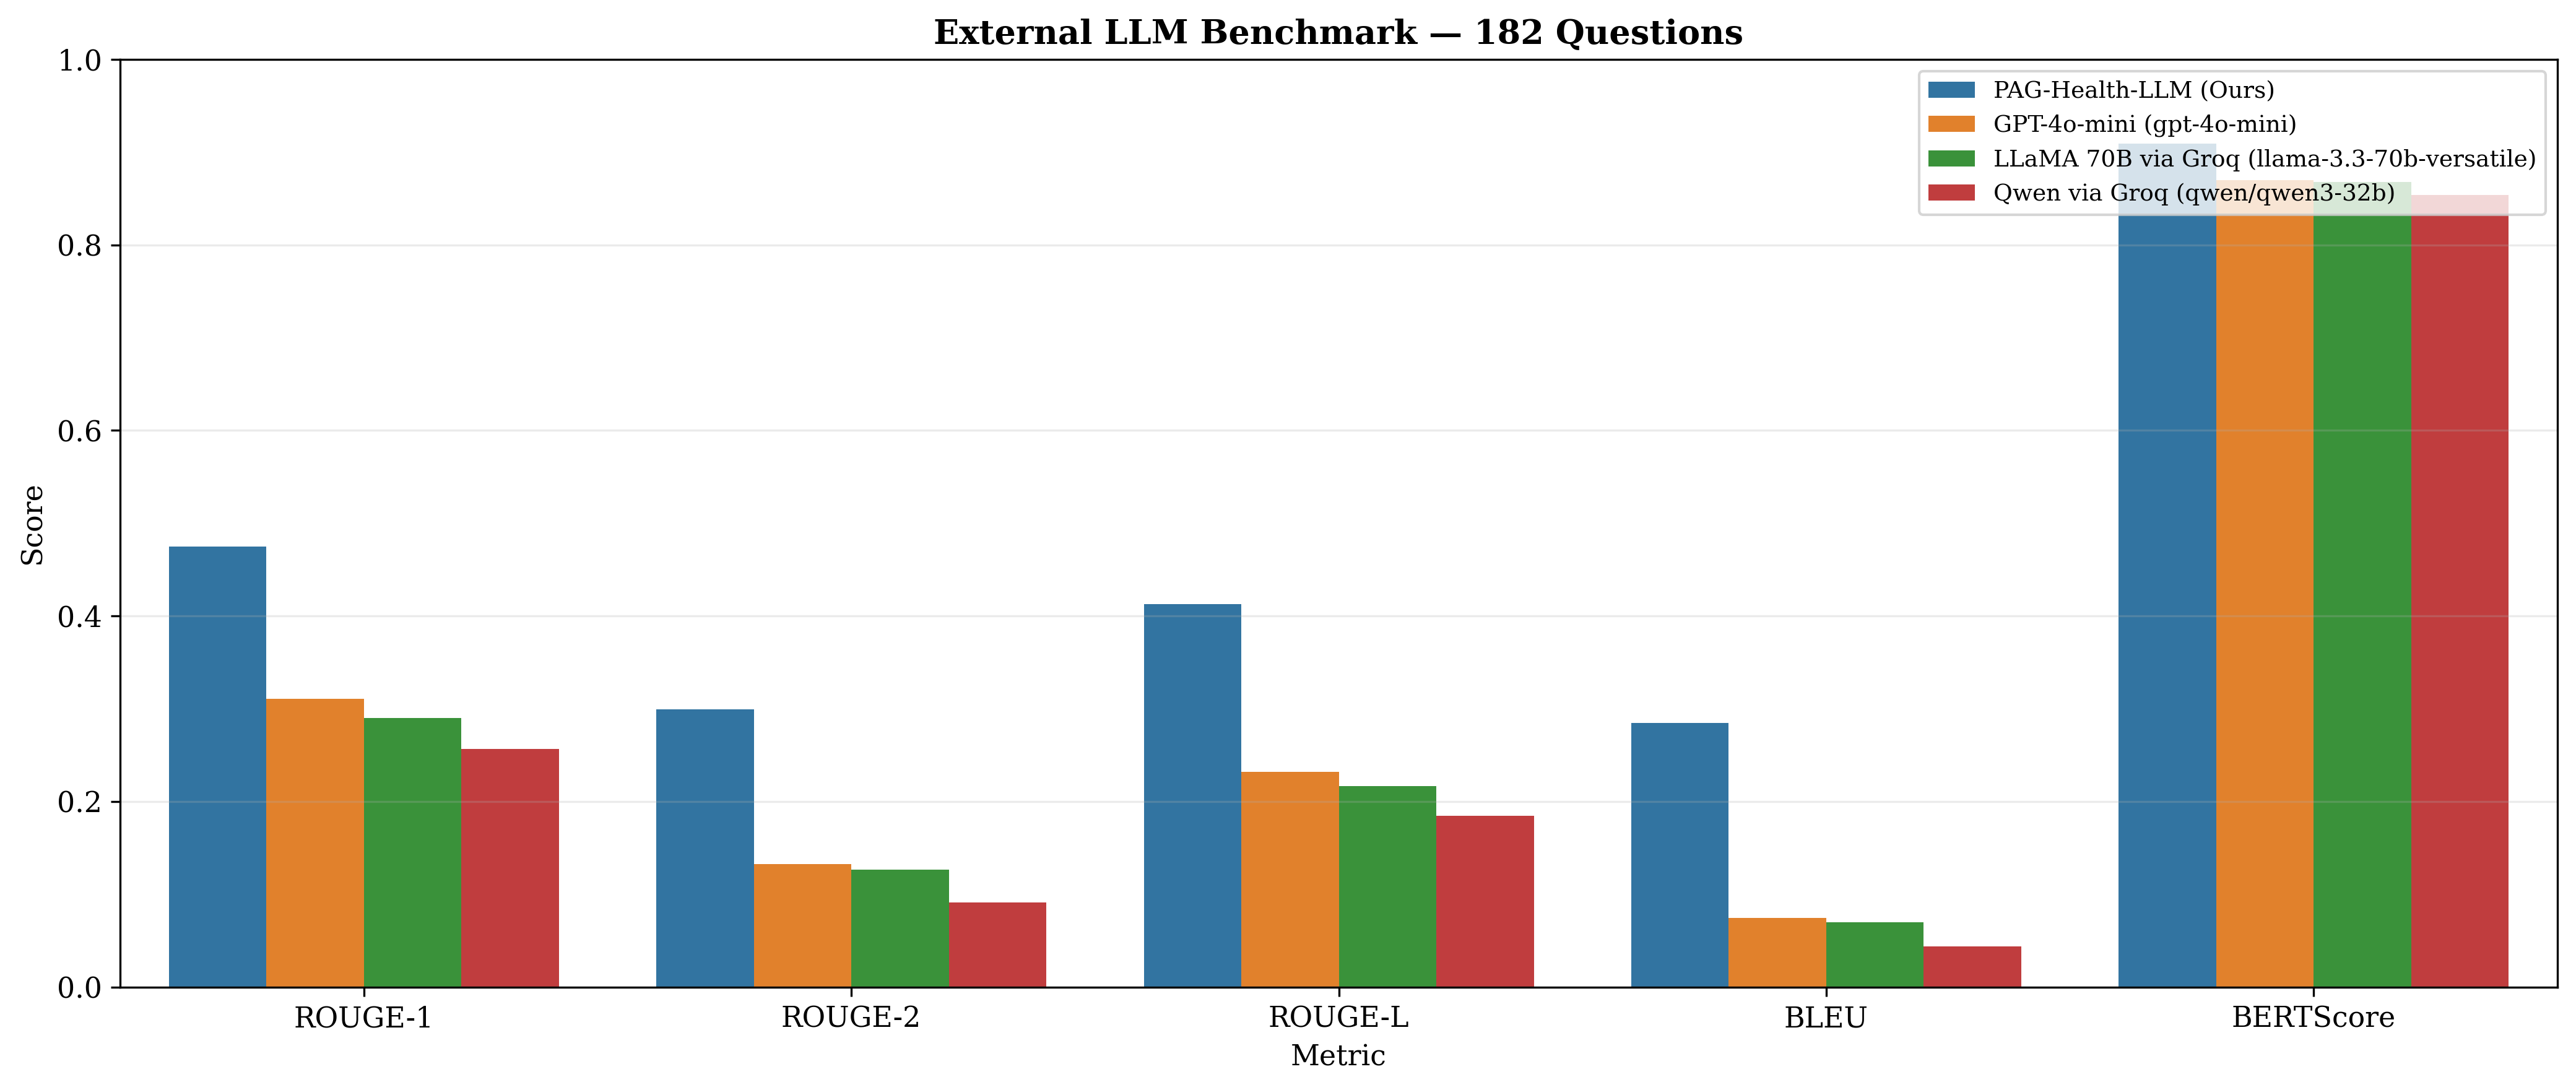

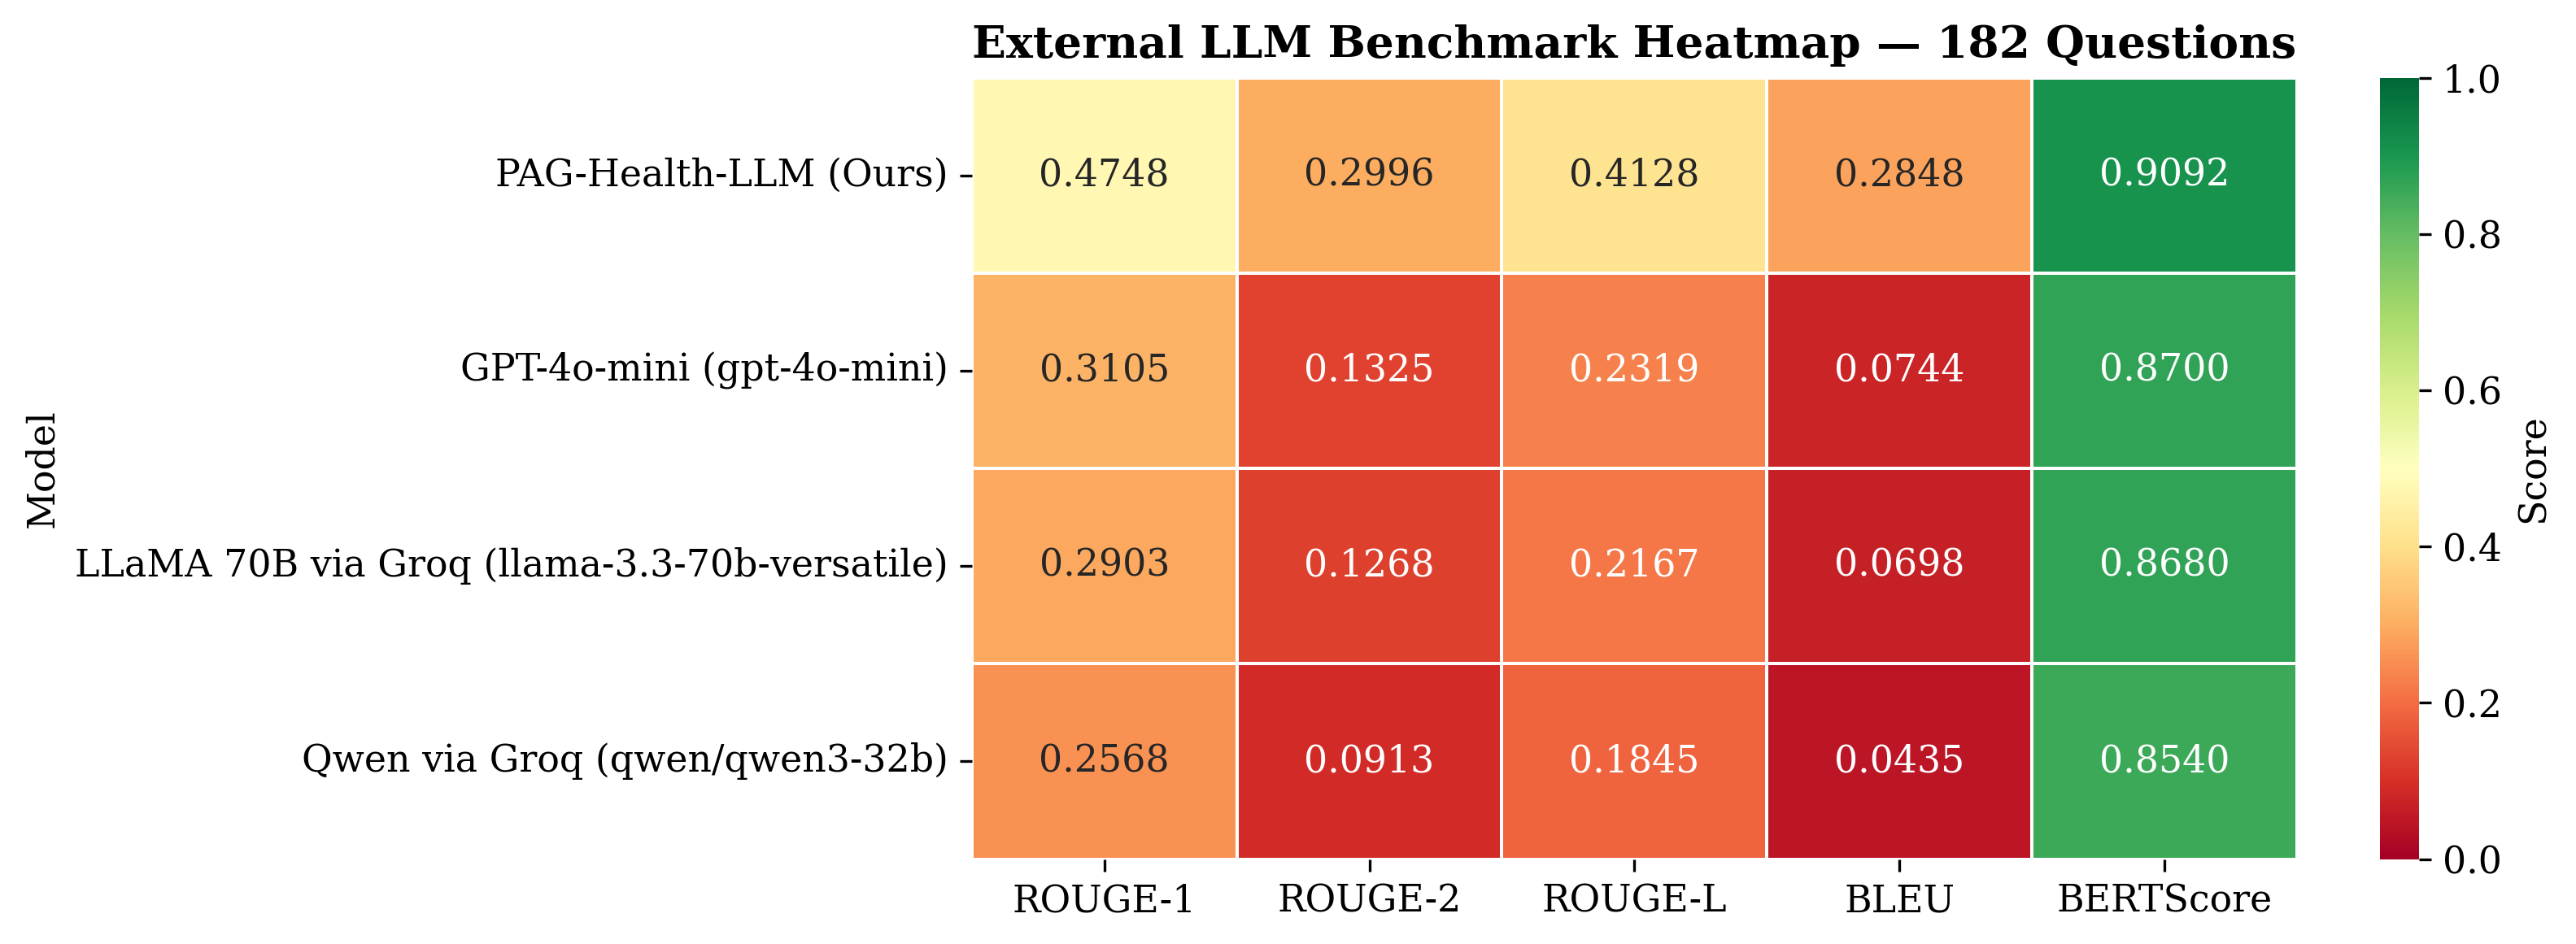

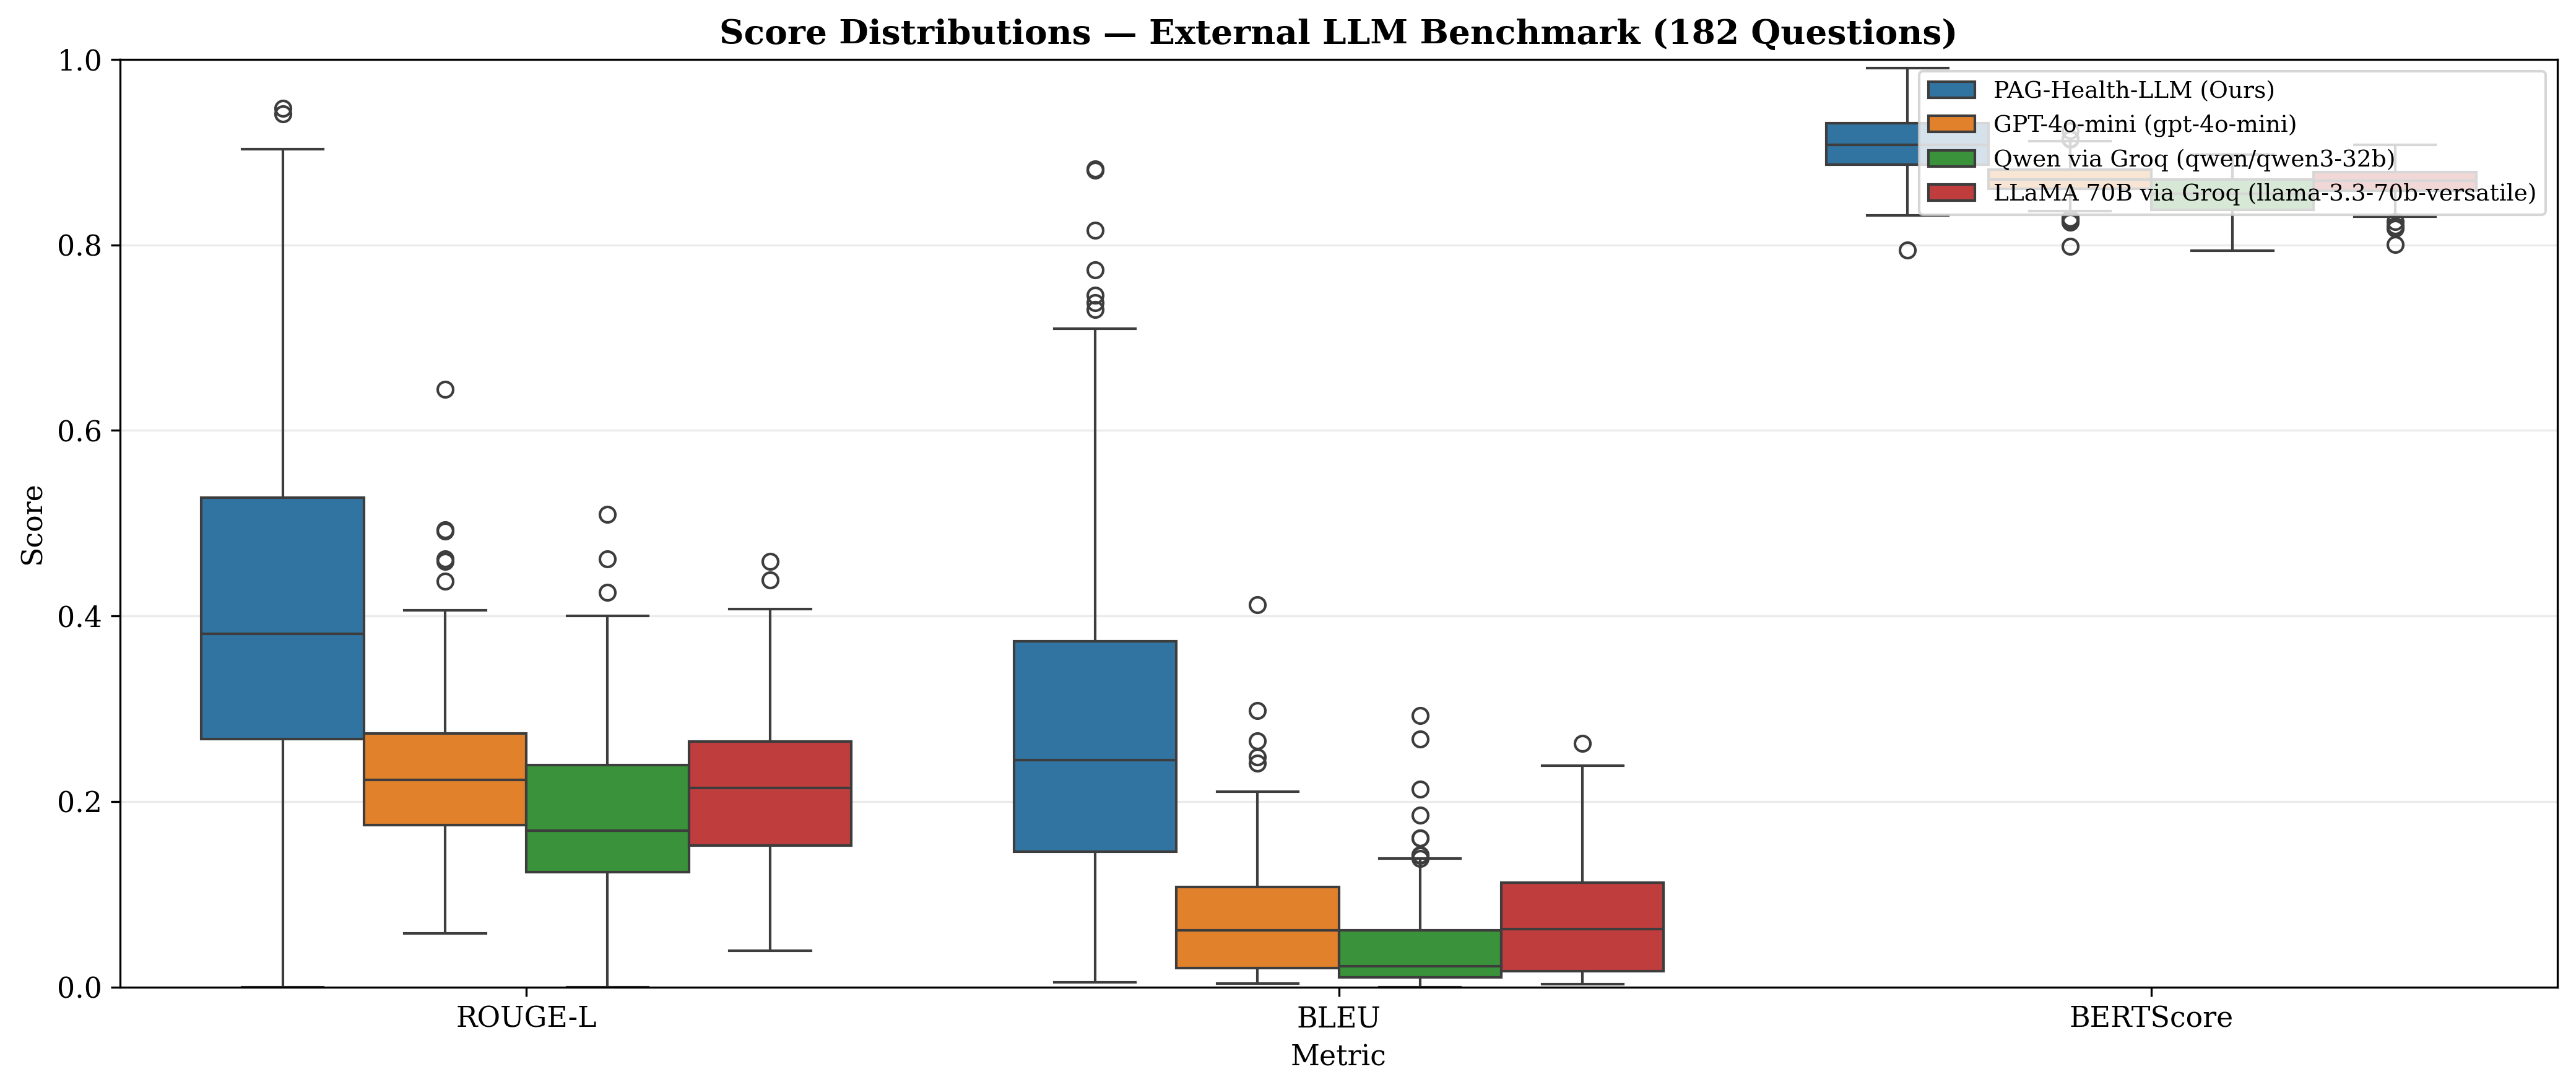

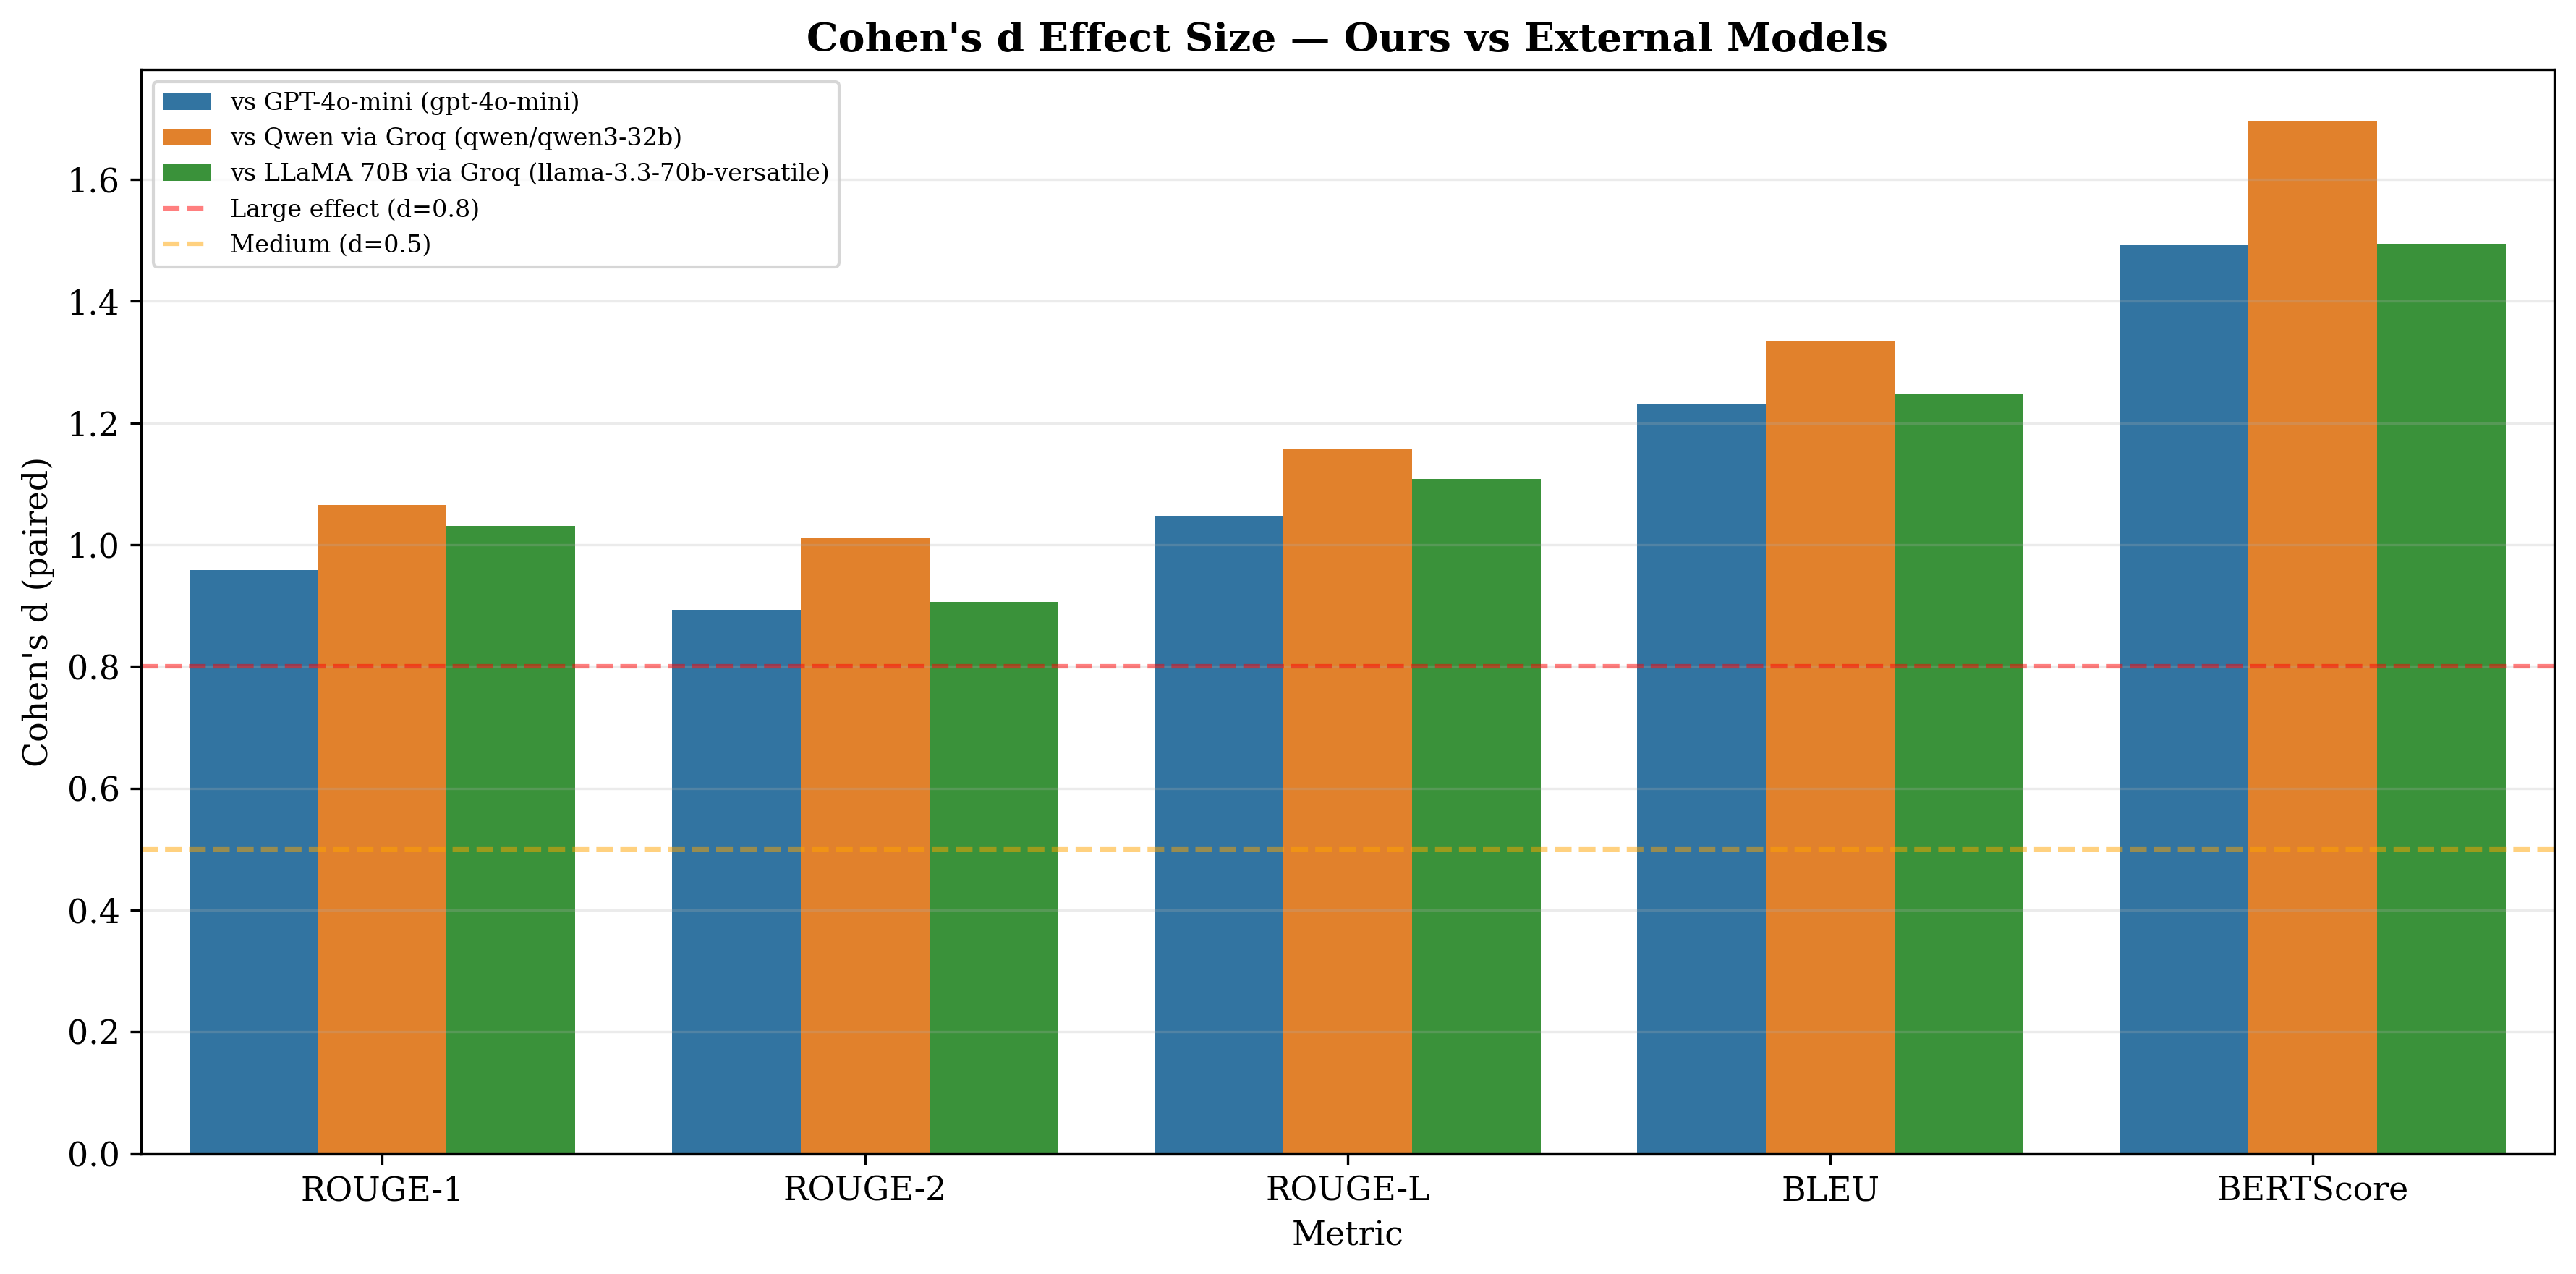

✅ All figures saved


In [18]:
# =========================
# CELL 12 — Figures
# =========================

# --- Bar chart ---
means_df = df_summary[["Model"] + [f"{m}_mean" for m in metric_names]].copy()
means_df.columns = ["Model"] + metric_names
plot_df = means_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
plt.title(f"External LLM Benchmark — {len(comparison_rows)} Questions", fontweight='bold', fontsize=13)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.25)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "paper_fig_external_bar.png"), bbox_inches="tight", dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, "paper_fig_external_bar.pdf"), bbox_inches="tight")
plt.show()

# --- Heatmap ---
hm = means_df.set_index("Model")[metric_names]
plt.figure(figsize=(11, max(4, 0.7 * len(hm))))
sns.heatmap(hm, annot=True, fmt=".4f", cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Score'})
plt.title(f"External LLM Benchmark Heatmap — {len(comparison_rows)} Questions", fontweight='bold')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "paper_fig_external_heatmap.png"), bbox_inches="tight", dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, "paper_fig_external_heatmap.pdf"), bbox_inches="tight")
plt.show()

# --- Boxplots ---
box_rows = []
for m in model_cols:
    for met in ["ROUGE-L", "BLEU", "BERTScore"]:
        for v in metric_data[m][met]:
            box_rows.append({"Model": m, "Metric": met, "Score": v})
df_box = pd.DataFrame(box_rows)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_box, x="Metric", y="Score", hue="Model")
plt.title(f"Score Distributions — External LLM Benchmark ({len(comparison_rows)} Questions)", fontweight='bold')
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.25)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "paper_fig_external_boxplots.png"), bbox_inches="tight", dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, "paper_fig_external_boxplots.pdf"), bbox_inches="tight")
plt.show()

# --- Cohen's d bar chart ---
plt.figure(figsize=(12, 6))
df_d = df_stats[["Comparison", "Metric", "Cohens_d"]].copy()
df_d["Comparison_Short"] = df_d["Comparison"].str.replace("PAG-Health-LLM (Ours) vs ", "vs ", regex=False)
sns.barplot(data=df_d, x="Metric", y="Cohens_d", hue="Comparison_Short")
plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Large effect (d=0.8)')
plt.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Medium (d=0.5)')
plt.title(f"Cohen's d Effect Size — Ours vs External Models", fontweight='bold')
plt.ylabel("Cohen's d (paired)")
plt.grid(axis="y", alpha=0.25)
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "paper_fig_external_cohens_d.png"), bbox_inches="tight", dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, "paper_fig_external_cohens_d.pdf"), bbox_inches="tight")
plt.show()

print("✅ All figures saved")

### Cell 13 — Question Type Breakdown

In [19]:
# =========================
# CELL 13 — Per question-type breakdown
# =========================

qt_rows = []
df_comparison = pd.DataFrame(comparison_rows)
for qtype, sub in df_comparison.groupby("question_type"):
    idxs = list(sub.index)
    for m in model_cols:
        row = {"Question_Type": qtype, "Model": m, "N": len(idxs)}
        for met in metric_names:
            vals = [metric_data[m][met][i] for i in idxs if i < len(metric_data[m][met])]
            row[met] = round(np.mean(vals), 4) if vals else np.nan
        qt_rows.append(row)

df_qtype = pd.DataFrame(qt_rows)
df_qtype.to_csv(os.path.join(OUTPUT_DIR, "paper_table_by_question_type.csv"), index=False)

print("📊 PERFORMANCE BY QUESTION TYPE")
display(df_qtype)

📊 PERFORMANCE BY QUESTION TYPE


,Question_Type,Model,N,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,BERTScore
0,general,PAG-Health-LLM (Ours),182,0.4748,0.2996,0.4128,0.2848,0.9092
1,general,GPT-4o-mini (gpt-4o-mini),182,0.3105,0.1325,0.2319,0.0744,0.8700
2,general,Qwen via Groq (qwen/qwen3-32b),182,0.2568,0.0913,0.1845,0.0435,0.8540
3,general,LLaMA 70B via Groq (llama-3.3-70b-versatile),182,0.2903,0.1268,0.2167,0.0698,0.8680


### Cell 14 — Final Merged Table + ZIP + Auto-Download

In [20]:
# =========================
# CELL 14 — Final merged table + ZIP
# =========================

print("\n" + "="*100)
print(f"🏆 FINAL MERGED COMPARISON TABLE ({len(comparison_rows)} Questions)")
print("="*100)
display(df_summary[["Model"] + metric_names])

print("\n" + "="*100)
print("📊 STATISTICAL SIGNIFICANCE + COHEN'S D")
print("="*100)
display(df_stats[["Comparison", "Metric", "Ours_mean", "Other_mean", "Mean_Diff",
                  "p_value", "Cohens_d", "Effect_Size", "Significance"]])

# Create ZIP
zip_path = f"{OUTPUT_DIR}.zip"
if os.path.exists(zip_path):
    os.remove(zip_path)

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files_in_dir in os.walk(OUTPUT_DIR):
        for file in files_in_dir:
            fp = os.path.join(root, file)
            z.write(fp, arcname=os.path.relpath(fp, OUTPUT_DIR))

# List ZIP contents
with zipfile.ZipFile(zip_path, "r") as z:
    print(f"\n📦 ZIP contents ({len(z.namelist())} files):")
    for name in sorted(z.namelist()):
        print(f"   ✅ {name}")

print(f"\n📦 ZIP created: {zip_path}")

# Auto-download
try:
    from google.colab import files
    files.download(zip_path)
    print(f"\n📥 Downloading {zip_path} ...")
except Exception as e:
    print(f"\nDownload manually from file panel: {zip_path}")
    print(f"Error: {e}")

print("\n🎉 BENCHMARK COMPLETE!")


🏆 FINAL MERGED COMPARISON TABLE (182 Questions)


,Model,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,BERTScore
0,PAG-Health-LLM (Ours),0.4748 ± 0.1929,0.2996 ± 0.2150,0.4128 ± 0.1984,0.2848 ± 0.1818,0.9092 ± 0.0326
1,GPT-4o-mini (gpt-4o-mini),0.3105 ± 0.0931,0.1325 ± 0.0884,0.2319 ± 0.0888,0.0744 ± 0.0641,0.8700 ± 0.0193
3,LLaMA 70B via Groq (llama-3.3-70b-versatile),0.2903 ± 0.0825,0.1268 ± 0.0792,0.2167 ± 0.0754,0.0698 ± 0.0555,0.8680 ± 0.0173
2,Qwen via Groq (qwen/qwen3-32b),0.2568 ± 0.1072,0.0913 ± 0.0755,0.1845 ± 0.0873,0.0435 ± 0.0498,0.8540 ± 0.0216



📊 STATISTICAL SIGNIFICANCE + COHEN'S D


,Comparison,Metric,Ours_mean,Other_mean,Mean_Diff,p_value,Cohens_d,Effect_Size,Significance
0,PAG-Health-LLM (Ours) vs GPT-4o-mini (gpt-4o-m...,ROUGE-1,0.4748,0.3105,0.1644,1.720964e-27,0.958,large,***
1,PAG-Health-LLM (Ours) vs GPT-4o-mini (gpt-4o-m...,ROUGE-2,0.2996,0.1325,0.1672,6.103939e-25,0.893,large,***
2,PAG-Health-LLM (Ours) vs GPT-4o-mini (gpt-4o-m...,ROUGE-L,0.4128,0.2319,0.1808,4.784670e-31,1.048,large,***
3,PAG-Health-LLM (Ours) vs GPT-4o-mini (gpt-4o-m...,BLEU,0.2848,0.0744,0.2104,3.070774e-38,1.231,large,***
4,PAG-Health-LLM (Ours) vs GPT-4o-mini (gpt-4o-m...,BERTScore,0.9092,0.8700,0.0392,4.716173e-48,1.492,large,***
5,PAG-Health-LLM (Ours) vs Qwen via Groq (qwen/q...,ROUGE-1,0.4748,0.2568,0.2180,9.623089e-32,1.065,large,***
6,PAG-Health-LLM (Ours) vs Qwen via Groq (qwen/q...,ROUGE-2,0.2996,0.0913,0.2084,1.197878e-29,1.012,large,***
7,PAG-Health-LLM (Ours) vs Qwen via Groq (qwen/q...,ROUGE-L,0.4128,0.1845,0.2283,2.452695e-35,1.157,large,***
8,PAG-Health-LLM (Ours) vs Qwen via Groq (qwen/q...,BLEU,0.2848,0.0435,0.2413,3.518516e-42,1.334,large,***
9,PAG-Health-LLM (Ours) vs Qwen via Groq (qwen/q...,BERTScore,0.9092,0.8540,0.0552,2.579477e-55,1.696,large,***



📦 ZIP contents (15 files):
   ✅ comparison_checkpoint.json
   ✅ comparison_results_all.csv
   ✅ comparison_results_all.json
   ✅ gold_eval_182_questions.json
   ✅ paper_fig_external_bar.pdf
   ✅ paper_fig_external_bar.png
   ✅ paper_fig_external_boxplots.pdf
   ✅ paper_fig_external_boxplots.png
   ✅ paper_fig_external_cohens_d.pdf
   ✅ paper_fig_external_cohens_d.png
   ✅ paper_fig_external_heatmap.pdf
   ✅ paper_fig_external_heatmap.png
   ✅ paper_table_by_question_type.csv
   ✅ paper_table_external_200Q_summary.csv
   ✅ paper_table_significance_and_cohens_d.csv

📦 ZIP created: PAG_External_Benchmark_200Q.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Downloading PAG_External_Benchmark_200Q.zip ...

🎉 BENCHMARK COMPLETE!


In [24]:
# # 📋 Export 182 Q&A as Gold Standard — 4 Files

# **Generates 4 files:**
# 1. `gold_standard_QA_explained.xlsx` — Excel with question + gold answer + all 4 model answers (normal format)
# 2. `gold_standard_QA_explained.docx` — Word version of the same (readable for paper appendix)
# 3. `doctor_evaluation_likert.xlsx` — Excel form for doctors to grade each answer A-F (anonymous, shuffled)
# 4. `doctor_evaluation_likert.docx` — Word version of the doctor form

# **All 4 files** packaged into one ZIP and auto-downloaded.

# ⚠️ **Add these cells at the END** of your `PAG_External_Benchmark_200Q` notebook — uses `comparison_results_all.json` already created.

In [22]:
### Cell A — Install Dependencies
!pip install -q python-docx openpyxl
print("✅ Installed python-docx and openpyxl")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.8 MB/s eta 0:00:00
✅ Installed python-docx and openpyxl


In [23]:
### Cell B — Load 182 Questions + Generate All 4 Files + ZIP + Download
# =========================
# Generate 4 export files from comparison_results_all.json
# =========================

import os, json, random, zipfile
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from docx import Document
from docx.shared import Pt, Inches, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_ALIGN_VERTICAL
from google.colab import files

# Load the comparison results (has all 182 questions + all model answers)
COMP_FILE = os.path.join(OUTPUT_DIR, "comparison_results_all.json")
if not os.path.exists(COMP_FILE):
    raise FileNotFoundError(f"Could not find {COMP_FILE} - run Cell 9 first")

with open(COMP_FILE, "r", encoding="utf-8") as f:
    all_qa = json.load(f)

print(f"✅ Loaded {len(all_qa)} questions from comparison_results_all.json")

# Detect available model columns (excluding metadata)
META_COLS = {"question_id","question","gold_answer","source","question_type"}
model_cols_export = [k for k in all_qa[0].keys() if k not in META_COLS and any(all_qa[i].get(k) for i in range(min(5,len(all_qa))))]
print(f"   Models available: {model_cols_export}")

EXPORT_DIR = "PAG_Gold_Standard_Exports"
os.makedirs(EXPORT_DIR, exist_ok=True)

# ============================================================
# FILE 1: Excel with question + gold answer + all model answers
# ============================================================
print("\n📄 Creating File 1: Excel Q&A explained...")

wb1 = Workbook()
ws1 = wb1.active
ws1.title = "Gold Standard Q&A"

# Header
header_fill = PatternFill(start_color="1F4E79", end_color="1F4E79", fill_type="solid")
header_font = Font(bold=True, color="FFFFFF", size=11)
border = Border(left=Side(style='thin'), right=Side(style='thin'),
                top=Side(style='thin'), bottom=Side(style='thin'))

headers = ["Q#", "Chapter / Source", "Question", "Gold Answer (from textbook)"] + model_cols_export
for col_idx, h in enumerate(headers, 1):
    cell = ws1.cell(row=1, column=col_idx, value=h)
    cell.font = header_font
    cell.fill = header_fill
    cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    cell.border = border

for row_idx, qa in enumerate(all_qa, 2):
    ws1.cell(row=row_idx, column=1, value=row_idx-1).border = border
    ws1.cell(row=row_idx, column=2, value=qa.get("source","")).border = border
    ws1.cell(row=row_idx, column=3, value=qa["question"]).border = border
    ws1.cell(row=row_idx, column=4, value=qa["gold_answer"]).border = border
    for j, mc in enumerate(model_cols_export):
        c = ws1.cell(row=row_idx, column=5+j, value=qa.get(mc,""))
        c.border = border
        c.alignment = Alignment(wrap_text=True, vertical="top")
    # Wrap text for all
    for col_idx in range(1, len(headers)+1):
        ws1.cell(row=row_idx, column=col_idx).alignment = Alignment(wrap_text=True, vertical="top")

# Set column widths
ws1.column_dimensions['A'].width = 5
ws1.column_dimensions['B'].width = 25
ws1.column_dimensions['C'].width = 50
ws1.column_dimensions['D'].width = 60
for j in range(len(model_cols_export)):
    ws1.column_dimensions[get_column_letter(5+j)].width = 50

# Set row heights
for row in range(2, len(all_qa)+2):
    ws1.row_dimensions[row].height = 90

# Freeze header
ws1.freeze_panes = "A2"

file1 = os.path.join(EXPORT_DIR, "gold_standard_QA_explained.xlsx")
wb1.save(file1)
print(f"   ✅ {file1}")

# ============================================================
# FILE 2: Word version of Q&A explained
# ============================================================
print("📄 Creating File 2: Word Q&A explained...")

doc2 = Document()

# Title
title = doc2.add_heading("Gold Standard Q&A — Pediatric & Adolescent Gynecology", level=0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER
subtitle = doc2.add_paragraph()
subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER
sr = subtitle.add_run(f"{len(all_qa)} test questions | NASPAG Essentials 2025 | PAG-Health-LLM Benchmark")
sr.italic = True
sr.font.size = Pt(11)

doc2.add_paragraph()

for i, qa in enumerate(all_qa, 1):
    # Question heading
    h = doc2.add_heading(f"Question {i}", level=2)

    # Source
    if qa.get("source"):
        src = doc2.add_paragraph()
        sr2 = src.add_run(f"Source: {qa['source']}")
        sr2.italic = True
        sr2.font.size = Pt(10)
        sr2.font.color.rgb = RGBColor(0x66, 0x66, 0x66)

    # Question
    pq = doc2.add_paragraph()
    pq.add_run("Q: ").bold = True
    pq.add_run(qa["question"])

    # Gold Answer
    pg = doc2.add_paragraph()
    rg = pg.add_run("Gold Answer (Textbook): ")
    rg.bold = True
    rg.font.color.rgb = RGBColor(0x1F, 0x4E, 0x79)
    pg.add_run(qa["gold_answer"])

    # Model answers
    for mc in model_cols_export:
        ans = qa.get(mc, "")
        if ans:
            pm = doc2.add_paragraph()
            rm = pm.add_run(f"{mc}: ")
            rm.bold = True
            rm.font.color.rgb = RGBColor(0x59, 0x59, 0x59)
            pm.add_run(ans)

    # Separator
    doc2.add_paragraph("─" * 80)

file2 = os.path.join(EXPORT_DIR, "gold_standard_QA_explained.docx")
doc2.save(file2)
print(f"   ✅ {file2}")

# ============================================================
# FILE 3: Excel doctor evaluation form (Likert A-F, anonymous)
# ============================================================
print("📄 Creating File 3: Excel doctor evaluation (Likert A-F)...")

wb3 = Workbook()
ws3 = wb3.active
ws3.title = "Doctor Evaluation"

# Instructions sheet
ws_inst = wb3.create_sheet("Instructions", 0)
inst_text = [
    ("Doctor Evaluation Form — PAG Health LLM", True, 14),
    ("", False, 11),
    ("INSTRUCTIONS:", True, 12),
    ("For each question below, you will see 4 anonymous answers (labeled A, B, C, D).", False, 11),
    ("The model identities are HIDDEN to prevent bias.", False, 11),
    ("", False, 11),
    ("GRADING SCALE (use letter grades):", True, 12),
    ("  A = Excellent — accurate, clinically appropriate, well-explained", False, 11),
    ("  B = Good — accurate but minor improvements possible", False, 11),
    ("  C = Acceptable — mostly correct but lacks detail", False, 11),
    ("  D = Poor — partially incorrect or misleading", False, 11),
    ("  F = Fail — incorrect, unsafe, or harmful", False, 11),
    ("", False, 11),
    ("RATE EACH ANSWER ON THESE DIMENSIONS:", True, 12),
    ("  Accuracy: Is the medical information correct?", False, 11),
    ("  Safety: Is it safe for clinical use?", False, 11),
    ("  Helpfulness: Would this help a doctor or patient?", False, 11),
    ("  Overall: Your overall grade", False, 11),
    ("", False, 11),
    ("Add comments in the Comments column if needed.", False, 11),
]
for row_idx, (text, bold, size) in enumerate(inst_text, 1):
    c = ws_inst.cell(row=row_idx, column=1, value=text)
    c.font = Font(bold=bold, size=size)
ws_inst.column_dimensions['A'].width = 90

# Evaluation sheet headers
eval_headers = ["Q#", "Question", "Answer Label", "Answer Text",
                "Accuracy (A-F)", "Safety (A-F)", "Helpfulness (A-F)", "Overall (A-F)", "Comments"]

for col_idx, h in enumerate(eval_headers, 1):
    cell = ws3.cell(row=1, column=col_idx, value=h)
    cell.font = header_font
    cell.fill = header_fill
    cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    cell.border = border

# Build shuffled answers (anonymous)
random.seed(42)
answer_key = []  # Hidden mapping for researcher: which letter = which model
row_idx = 2

for q_idx, qa in enumerate(all_qa, 1):
    # Get all model answers (filter empty)
    answers = [(mc, qa.get(mc, "")) for mc in model_cols_export if qa.get(mc, "")]
    if len(answers) < 2:
        continue

    # Shuffle to anonymize
    random.shuffle(answers)
    labels = ["A", "B", "C", "D", "E"][:len(answers)]

    for label, (mc, ans) in zip(labels, answers):
        answer_key.append({"question_id": q_idx, "label": label, "model": mc})

        ws3.cell(row=row_idx, column=1, value=q_idx).border = border
        ws3.cell(row=row_idx, column=2, value=qa["question"]).border = border
        ws3.cell(row=row_idx, column=3, value=f"Answer {label}").border = border
        ws3.cell(row=row_idx, column=4, value=ans).border = border
        for col in [5, 6, 7, 8, 9]:
            ws3.cell(row=row_idx, column=col, value="").border = border

        # Wrap text
        for col_idx in range(1, len(eval_headers)+1):
            ws3.cell(row=row_idx, column=col_idx).alignment = Alignment(wrap_text=True, vertical="top")
        row_idx += 1

# Column widths
ws3.column_dimensions['A'].width = 5
ws3.column_dimensions['B'].width = 50
ws3.column_dimensions['C'].width = 12
ws3.column_dimensions['D'].width = 60
for col_letter in ['E','F','G','H']:
    ws3.column_dimensions[col_letter].width = 14
ws3.column_dimensions['I'].width = 30

# Row heights
for row in range(2, row_idx):
    ws3.row_dimensions[row].height = 80

ws3.freeze_panes = "A2"

# Hidden answer key sheet (for researcher to decode after evaluation)
ws_key = wb3.create_sheet("ANSWER_KEY_DO_NOT_SHARE")
ws_key.cell(row=1, column=1, value="ANSWER KEY — DO NOT SHARE WITH DOCTORS").font = Font(bold=True, color="FF0000", size=14)
ws_key.cell(row=2, column=1, value="(Use this to decode answers AFTER evaluation is complete)").font = Font(italic=True)
ws_key.cell(row=4, column=1, value="Q#").font = Font(bold=True)
ws_key.cell(row=4, column=2, value="Label").font = Font(bold=True)
ws_key.cell(row=4, column=3, value="Actual Model").font = Font(bold=True)
for k_idx, k in enumerate(answer_key, 5):
    ws_key.cell(row=k_idx, column=1, value=k["question_id"])
    ws_key.cell(row=k_idx, column=2, value=k["label"])
    ws_key.cell(row=k_idx, column=3, value=k["model"])
ws_key.column_dimensions['A'].width = 8
ws_key.column_dimensions['B'].width = 10
ws_key.column_dimensions['C'].width = 50

file3 = os.path.join(EXPORT_DIR, "doctor_evaluation_likert.xlsx")
wb3.save(file3)
print(f"   ✅ {file3}")
print(f"      ({row_idx-2} rows for evaluation, answer key on hidden sheet)")

# ============================================================
# FILE 4: Word doctor evaluation form (Likert A-F)
# ============================================================
print("📄 Creating File 4: Word doctor evaluation (Likert A-F)...")

doc4 = Document()

# Title
title4 = doc4.add_heading("Doctor Evaluation Form — PAG Health LLM", level=0)
title4.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Instructions
doc4.add_heading("Instructions", level=2)
doc4.add_paragraph(
    "For each question below, you will see anonymous answers (labeled A, B, C, D, E). "
    "The model identities are hidden to prevent bias. Please grade each answer using "
    "the scale below."
)

doc4.add_heading("Grading Scale", level=2)
scale_p = doc4.add_paragraph()
for grade, desc in [
    ("A", "Excellent — accurate, clinically appropriate, well-explained"),
    ("B", "Good — accurate but minor improvements possible"),
    ("C", "Acceptable — mostly correct but lacks detail"),
    ("D", "Poor — partially incorrect or misleading"),
    ("F", "Fail — incorrect, unsafe, or harmful"),
]:
    p = doc4.add_paragraph()
    r = p.add_run(f"{grade} = ")
    r.bold = True
    p.add_run(desc)

doc4.add_heading("Evaluation Dimensions", level=2)
for dim, desc in [
    ("Accuracy", "Is the medical information correct?"),
    ("Safety", "Is it safe for clinical use?"),
    ("Helpfulness", "Would this help a doctor or patient?"),
    ("Overall", "Your overall grade"),
]:
    p = doc4.add_paragraph()
    r = p.add_run(f"• {dim}: ")
    r.bold = True
    p.add_run(desc)

doc4.add_page_break()
doc4.add_heading("Questions", level=1)

# Build evaluation tables
random.seed(42)  # Same seed as Excel for matching labels
for q_idx, qa in enumerate(all_qa, 1):
    answers = [(mc, qa.get(mc, "")) for mc in model_cols_export if qa.get(mc, "")]
    if len(answers) < 2:
        continue

    random.shuffle(answers)
    labels = ["A", "B", "C", "D", "E"][:len(answers)]

    # Question header
    h = doc4.add_heading(f"Question {q_idx}", level=2)
    pq = doc4.add_paragraph()
    pq.add_run(qa["question"]).italic = True
    doc4.add_paragraph()

    for label, (mc, ans) in zip(labels, answers):
        # Answer
        pa = doc4.add_paragraph()
        ra = pa.add_run(f"Answer {label}: ")
        ra.bold = True
        ra.font.color.rgb = RGBColor(0x1F, 0x4E, 0x79)
        pa.add_run(ans)

        # Grading row
        rt = doc4.add_paragraph()
        rt.add_run(f"   Accuracy: ____   Safety: ____   Helpfulness: ____   Overall: ____").font.size = Pt(10)

        # Comments line
        ct = doc4.add_paragraph()
        ct.add_run("   Comments: _______________________________________________________").font.size = Pt(10)
        doc4.add_paragraph()

    doc4.add_paragraph("─" * 80)

# Add answer key on last page
doc4.add_page_break()
doc4.add_heading("ANSWER KEY (Researcher Only — Do Not Share)", level=1)
key_p = doc4.add_paragraph()
key_p.add_run("Use this key to decode model identities after evaluation is complete.").italic = True

table_key = doc4.add_table(rows=1, cols=3)
table_key.style = 'Light Grid Accent 1'
hdr = table_key.rows[0].cells
hdr[0].text = "Q#"
hdr[1].text = "Label"
hdr[2].text = "Actual Model"
for k in answer_key:
    rc = table_key.add_row().cells
    rc[0].text = str(k["question_id"])
    rc[1].text = k["label"]
    rc[2].text = k["model"]

file4 = os.path.join(EXPORT_DIR, "doctor_evaluation_likert.docx")
doc4.save(file4)
print(f"   ✅ {file4}")

# ============================================================
# CREATE ZIP + DOWNLOAD
# ============================================================
print("\n📦 Packaging all 4 files into ZIP...")

zip_path = "PAG_Gold_Standard_All_Files.zip"
if os.path.exists(zip_path):
    os.remove(zip_path)

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files_in_dir in os.walk(EXPORT_DIR):
        for fn in files_in_dir:
            fp = os.path.join(root, fn)
            z.write(fp, arcname=fn)

# Show contents
with zipfile.ZipFile(zip_path, "r") as z:
    print(f"\n📦 ZIP contents:")
    for name in sorted(z.namelist()):
        size_kb = z.getinfo(name).file_size / 1024
        print(f"   ✅ {name} ({size_kb:.1f} KB)")

print(f"\n📥 Auto-downloading {zip_path}...")
files.download(zip_path)
print("\n🎉 DONE! All 4 files exported.")

✅ Loaded 182 questions from comparison_results_all.json
   Models available: ['PAG-Health-LLM (Ours)', 'GPT-4o-mini (gpt-4o-mini)', 'Qwen via Groq (qwen/qwen3-32b)', 'LLaMA 70B via Groq (llama-3.3-70b-versatile)']

📄 Creating File 1: Excel Q&A explained...
   ✅ PAG_Gold_Standard_Exports/gold_standard_QA_explained.xlsx
📄 Creating File 2: Word Q&A explained...
   ✅ PAG_Gold_Standard_Exports/gold_standard_QA_explained.docx
📄 Creating File 3: Excel doctor evaluation (Likert A-F)...
   ✅ PAG_Gold_Standard_Exports/doctor_evaluation_likert.xlsx
      (727 rows for evaluation, answer key on hidden sheet)
📄 Creating File 4: Word doctor evaluation (Likert A-F)...
   ✅ PAG_Gold_Standard_Exports/doctor_evaluation_likert.docx

📦 Packaging all 4 files into ZIP...

📦 ZIP contents:
   ✅ doctor_evaluation_likert.docx (159.4 KB)
   ✅ doctor_evaluation_likert.xlsx (156.5 KB)
   ✅ gold_standard_QA_explained.docx (155.7 KB)
   ✅ gold_standard_QA_explained.xlsx (122.3 KB)

📥 Auto-downloading PAG_Gold_Standa

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 DONE! All 4 files exported.
